In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset: The dataset is loaded using Pandas for further analysis.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/House_Rent_Dataset.csv')

In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [ ]:
df.shape

(4746, 12)

In [ ]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

Dataset Information: This step shows the number of rows, columns, data types, and non-null values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


Missing Value Analysis: This checks whether any columns contain missing values.

In [ ]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


Observation: The dataset contains no missing values. All 12 columns have 0 missing values, so no missing-value treatment or imputation is required.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


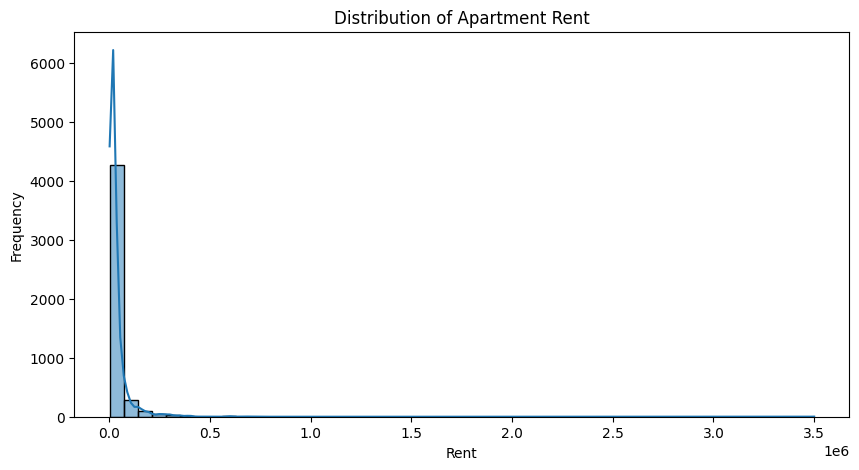

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Rent'], bins=50, kde=True)

plt.title('Distribution of Apartment Rent')
plt.xlabel('Rent')
plt.ylabel('Frequency')

plt.show()

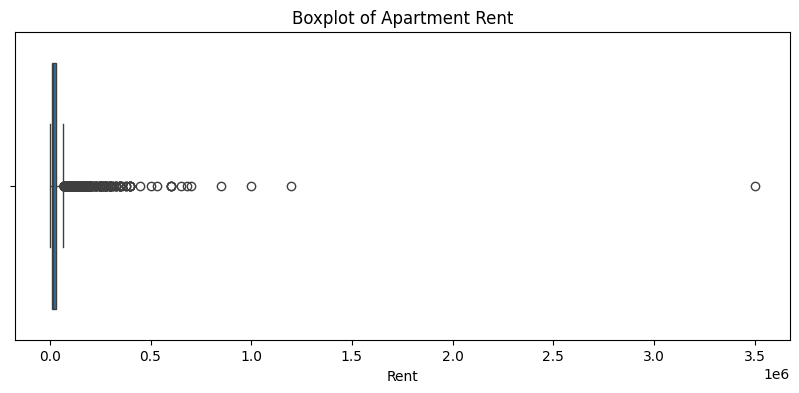

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Rent'])

plt.title('Boxplot of Apartment Rent')
plt.xlabel('Rent')

plt.show()

In [ ]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 10000.0
Q3: 33000.0
IQR: 23000.0
Lower Bound: -24500.0
Upper Bound: 67500.0


In [ ]:
outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 520


### Outlier Analysis

The IQR method identified 520 potential outliers in the Rent variable. These observations represent approximately 11% of the dataset. Since high rental values may represent genuine properties rather than errors, the observations will not be removed automatically. Further analysis will be performed before deciding on the appropriate preprocessing method.

## BHK Analysis

BHK represents the number of bedrooms in a property. We analyze its distribution to understand the types of rental properties present in the dataset.

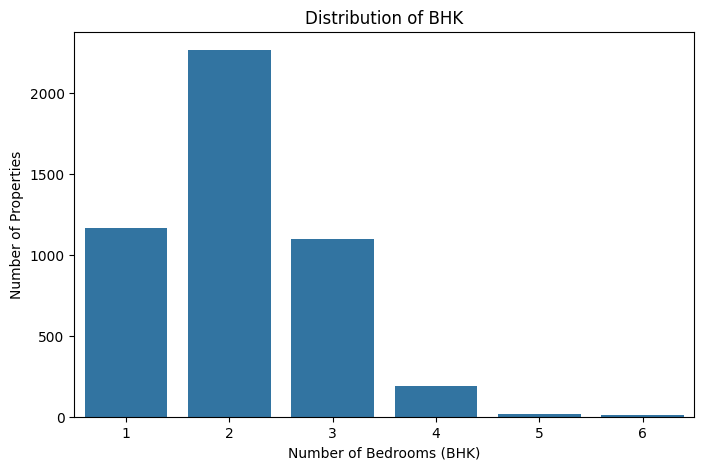

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='BHK', data=df)

plt.title('Distribution of BHK')
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Number of Properties')

plt.show()

In [ ]:
df['BHK'].value_counts().sort_index()

,count
BHK,
1,1167
2,2265
3,1098
4,189
5,19
6,8


### Observation

The dataset contains properties ranging from 1 BHK to 6 BHK. 2 BHK properties are the most common, with 2,265 listings, followed by 1 BHK with 1,167 listings and 3 BHK with 1,098 listings. Properties with 4 or more BHKs are much less common. This shows that the dataset is mainly composed of small to medium-sized rental properties.

### Relationship Between BHK and Rent

We analyze the relationship between the number of bedrooms and rental prices to determine whether properties with different numbers of bedrooms have different rent distributions.

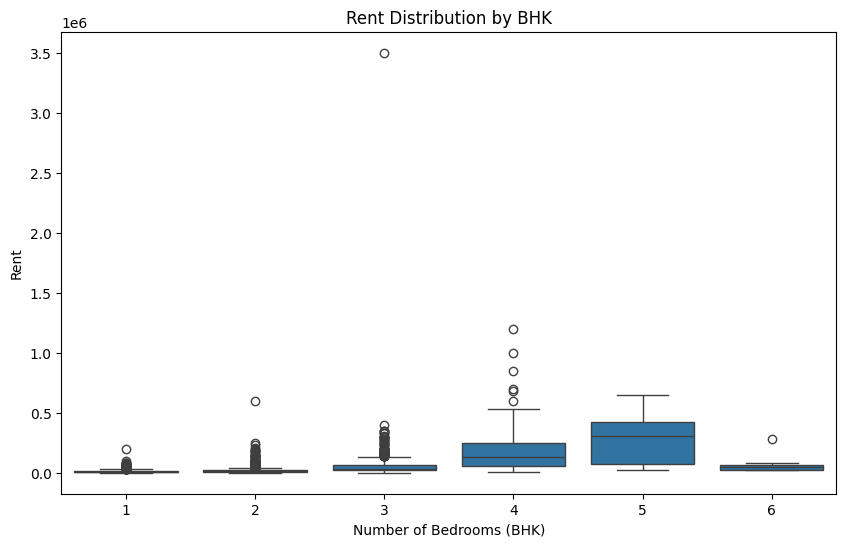

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='BHK', y='Rent', data=df)

plt.title('Rent Distribution by BHK')
plt.xlabel('Number of Bedrooms (BHK)')
plt.ylabel('Rent')

plt.show()

In [ ]:
df.groupby('BHK')['Rent'].mean().round(2)

,Rent
BHK,
1,14139.22
2,22113.86
3,55863.06
4,168864.56
5,297500.00
6,73125.00


### Observation

The average rent generally increases as the number of bedrooms increases. The average rent is approximately Rs. 14,139 for 1 BHK, Rs. 22,114 for 2 BHK, and Rs. 55,863 for 3 BHK properties. Properties with 4 and 5 BHK have much higher average rents. This indicates that BHK is an important factor that may help predict rental prices.

## 9. Size Analysis

Size represents the approximate area of the rental property in square feet. We analyze its distribution to understand the typical property sizes in the dataset.

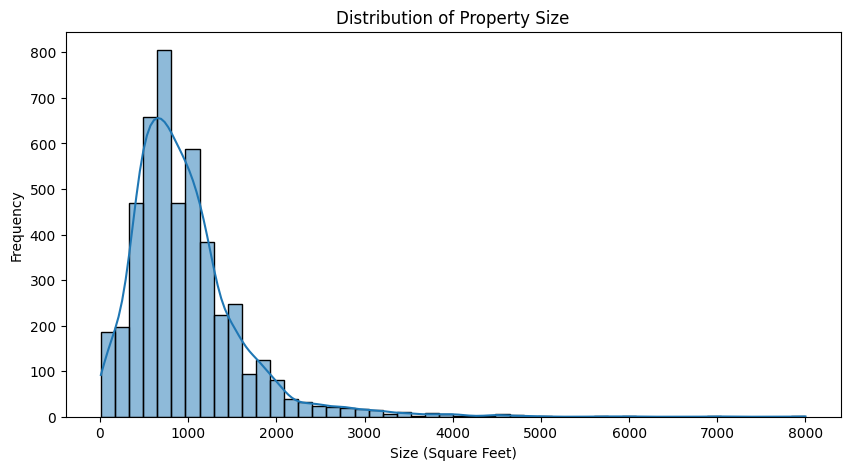

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Size'], bins=50, kde=True)

plt.title('Distribution of Property Size')
plt.xlabel('Size (Square Feet)')
plt.ylabel('Frequency')

plt.show()

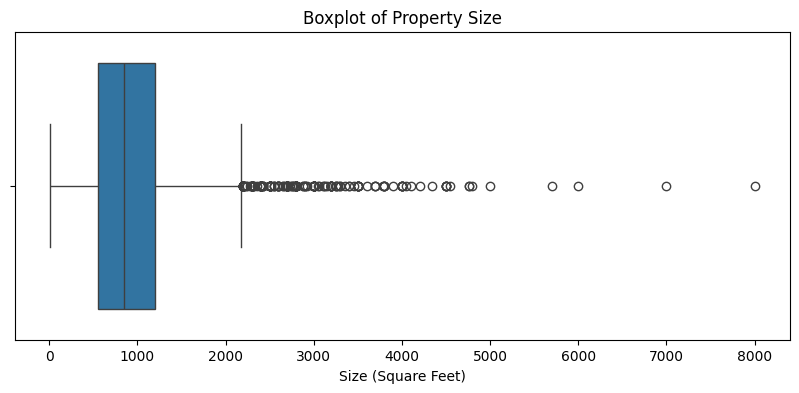

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Size'])

plt.title('Boxplot of Property Size')
plt.xlabel('Size (Square Feet)')

plt.show()

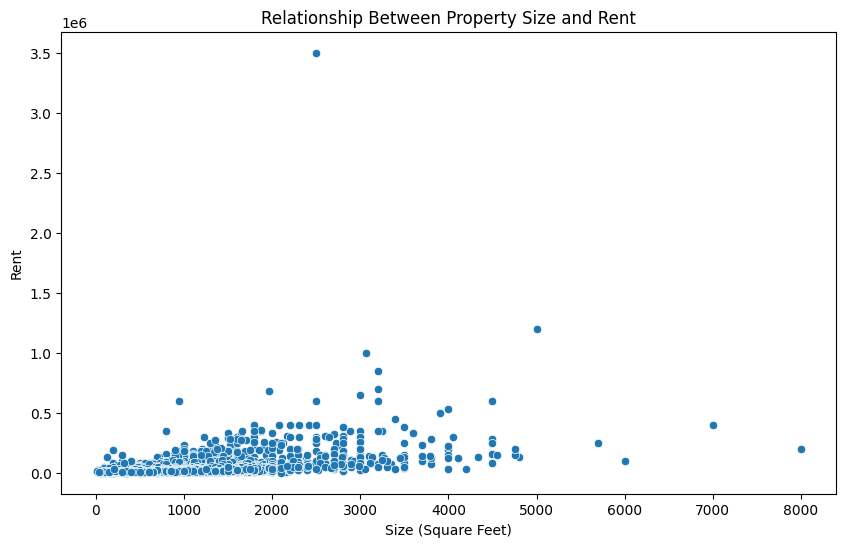

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Size', y='Rent', data=df)

plt.title('Relationship Between Property Size and Rent')
plt.xlabel('Size (Square Feet)')
plt.ylabel('Rent')

plt.show()

In [ ]:
df[['Size', 'Rent']].corr()

,Size,Rent
Size,1.000000,0.413551
Rent,0.413551,1.000000


### Observation

The correlation between Size and Rent is 0.414, indicating a moderate positive relationship. This suggests that larger properties generally tend to have higher rental prices. Therefore, Size is likely to be a useful feature for predicting Rent.

## 10. Bathroom Analysis

Bathroom represents the number of bathrooms available in a rental property. We analyze its distribution to understand the common number of bathrooms among the properties.

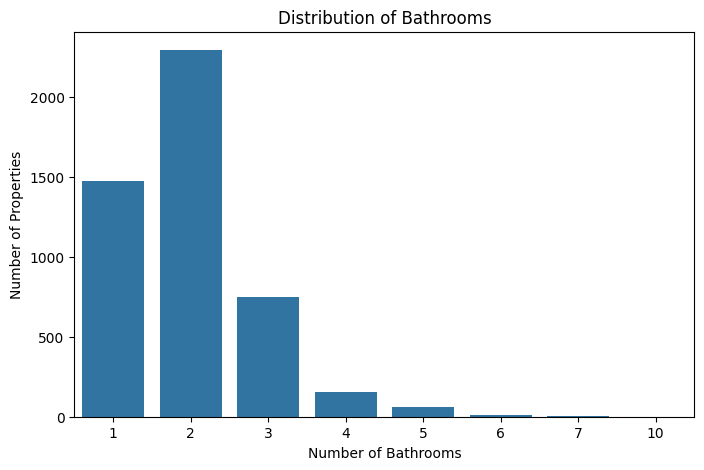

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Bathroom', data=df)

plt.title('Distribution of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Properties')

plt.show()

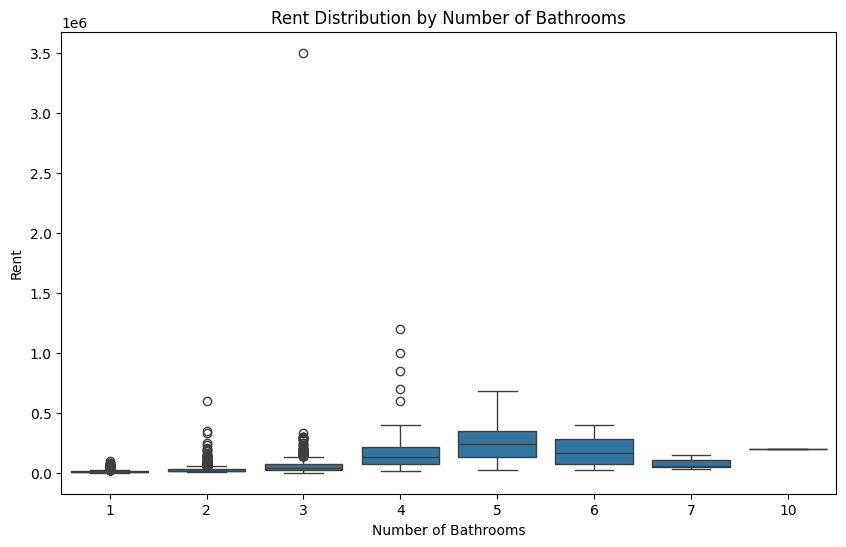

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Bathroom', y='Rent', data=df)

plt.title('Rent Distribution by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Rent')

plt.show()

In [ ]:
df.groupby('Bathroom')['Rent'].mean().round(2)

,Rent
Bathroom,
1,11862.16
2,25043.54
3,63176.70
4,167846.15
5,252350.00
6,177500.00
7,81666.67
10,200000.00


### Observation

The average rent generally increases as the number of bathrooms increases. Properties with 1 bathroom have an average rent of approximately Rs. 11,862, while properties with 2 and 3 bathrooms have average rents of approximately Rs. 25,044 and Rs. 63,177, respectively. Properties with a higher number of bathrooms show substantially higher average rents. However, some categories such as 6, 7, and 10 bathrooms contain relatively few properties, so their average rents should be interpreted with caution. Overall, Bathroom appears to be a useful feature for predicting Rent.

## 11. City Analysis

City represents the location of the rental property. Rental prices can vary between cities, so we analyze the distribution of properties across cities and their relationship with Rent.

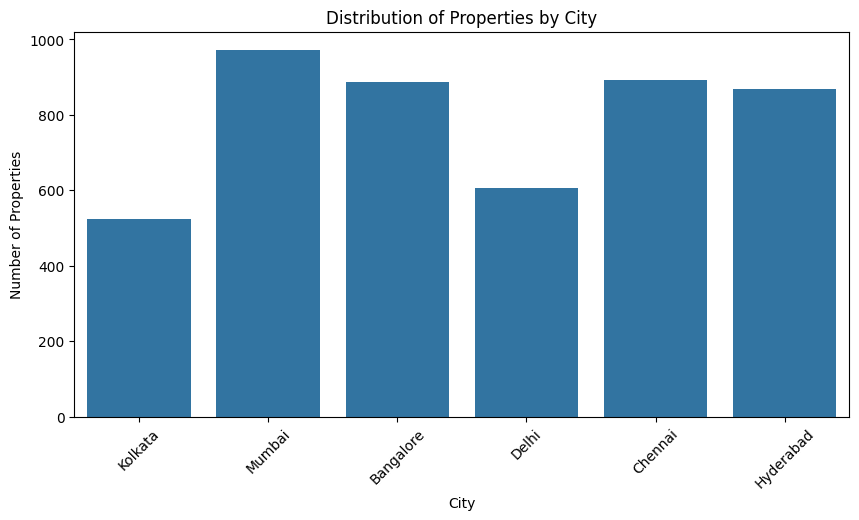

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(x='City', data=df)

plt.title('Distribution of Properties by City')
plt.xlabel('City')
plt.ylabel('Number of Properties')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['City'].value_counts()

,count
City,
Mumbai,972
Chennai,891
Bangalore,886
Hyderabad,868
Delhi,605
Kolkata,524


In [ ]:
city_rent = df.groupby('City')['Rent'].mean().sort_values(ascending=False)

city_rent

,Rent
City,
Mumbai,85321.204733
Delhi,29461.983471
Bangalore,24966.365688
Chennai,21614.092031
Hyderabad,20555.048387
Kolkata,11645.173664


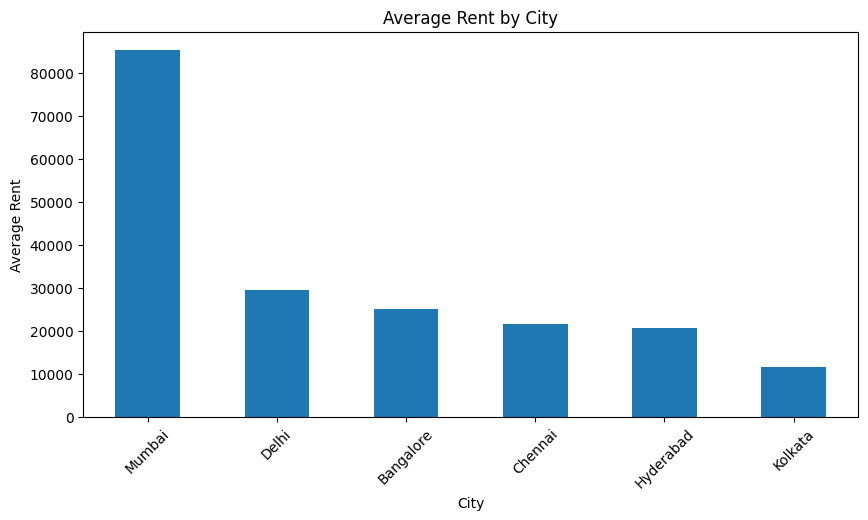

In [ ]:
plt.figure(figsize=(10, 5))

city_rent.plot(kind='bar')

plt.title('Average Rent by City')
plt.xlabel('City')
plt.ylabel('Average Rent')

plt.xticks(rotation=45)

plt.show()

In [ ]:
city_rent

,Rent
City,
Mumbai,85321.204733
Delhi,29461.983471
Bangalore,24966.365688
Chennai,21614.092031
Hyderabad,20555.048387
Kolkata,11645.173664


### Observation

The average rent varies considerably across cities. Mumbai has the highest average rent at approximately Rs. 85,321, followed by Delhi at Rs. 29,462 and Bangalore at Rs. 24,966. Kolkata has the lowest average rent at approximately Rs. 11,645. This indicates that City is an important factor that may help predict rental prices.

### Note

The differences in average rent across cities suggest that location may have a strong influence on rental prices.

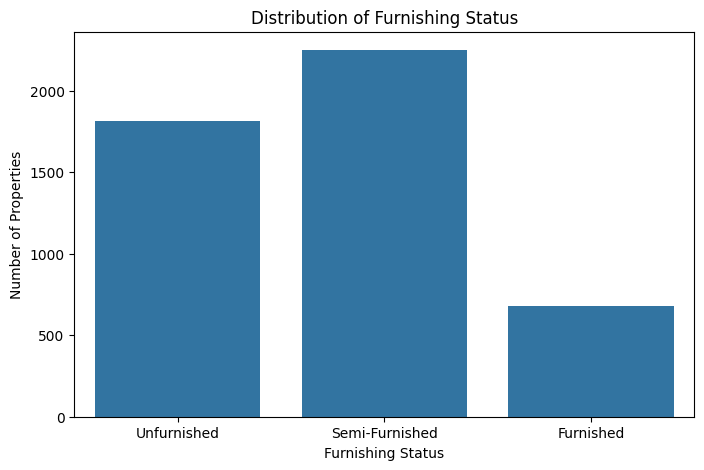

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Furnishing Status', data=df)

plt.title('Distribution of Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Number of Properties')

plt.show()

In [ ]:
furnishing_rent = df.groupby('Furnishing Status')['Rent'].mean().sort_values(ascending=False)

furnishing_rent

,Rent
Furnishing Status,
Furnished,56110.305882
Semi-Furnished,38718.810751
Unfurnished,22461.635813


### Observation

The average rent varies by furnishing status. Furnished properties have the highest average rent at approximately Rs. 56,110, followed by semi-furnished properties at Rs. 38,719. Unfurnished properties have the lowest average rent at approximately Rs. 22,462. This suggests that furnishing status may be an important feature for predicting rental prices.

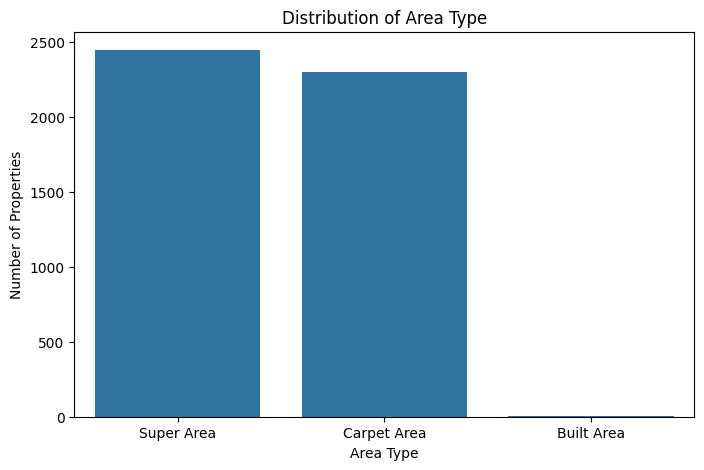

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Area Type', data=df)

plt.title('Distribution of Area Type')
plt.xlabel('Area Type')
plt.ylabel('Number of Properties')

plt.show()

In [ ]:
area_type_rent = df.groupby('Area Type')['Rent'].mean().sort_values(ascending=False)

area_type_rent

,Rent
Area Type,
Carpet Area,52385.897302
Super Area,18673.396566
Built Area,10500.000000


### Observation

The average rent varies across different area types. Properties classified as Carpet Area have the highest average rent at approximately Rs. 52,386, followed by Super Area at Rs. 18,673. Built Area has the lowest average rent at approximately Rs. 10,500. This suggests that Area Type may have an influence on rental prices and could be useful for predicting Rent.

## 13. Tenant Preferred Analysis

Tenant Preferred indicates the type of tenant preferred by the property owner. We analyze its distribution and relationship with Rent to determine whether tenant preference is associated with rental prices.

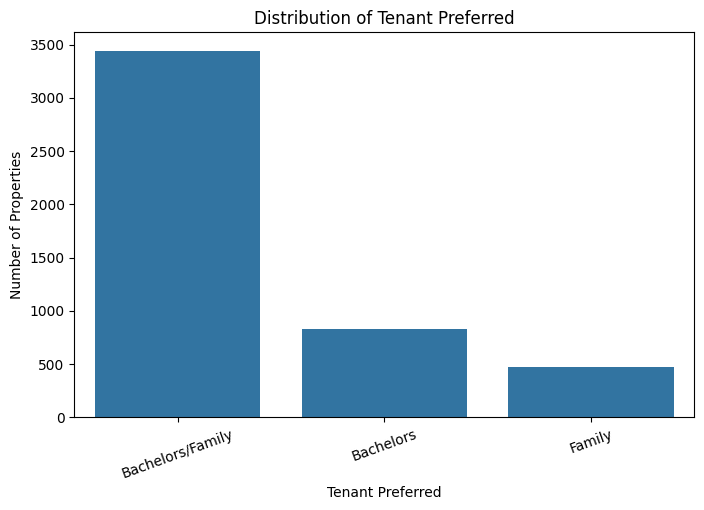

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Tenant Preferred', data=df)

plt.title('Distribution of Tenant Preferred')
plt.xlabel('Tenant Preferred')
plt.ylabel('Number of Properties')

plt.xticks(rotation=20)

plt.show()

In [ ]:
tenant_rent = df.groupby('Tenant Preferred')['Rent'].mean().sort_values(ascending=False)

tenant_rent

,Rent
Tenant Preferred,
Family,50020.341102
Bachelors,42143.793976
Bachelors/Family,31210.792683


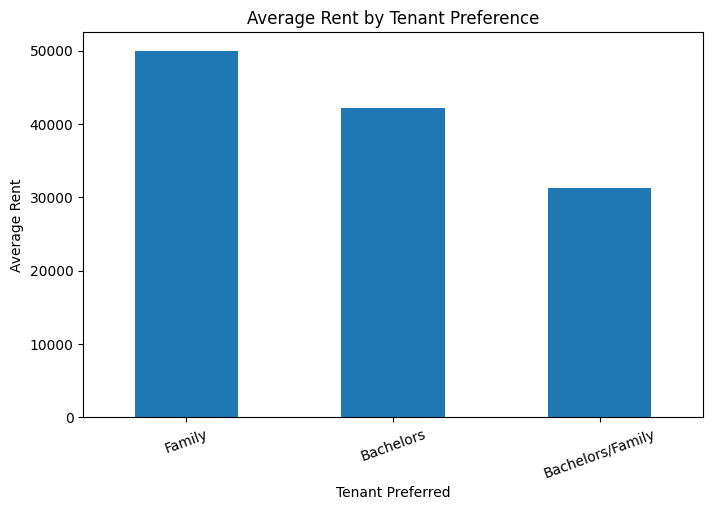

In [ ]:
plt.figure(figsize=(8, 5))

tenant_rent.plot(kind='bar')

plt.title('Average Rent by Tenant Preference')
plt.xlabel('Tenant Preferred')
plt.ylabel('Average Rent')

plt.xticks(rotation=20)

plt.show()

### Observation

The average rent varies according to tenant preference. Properties preferred for families have the highest average rent at approximately Rs. 50,020, followed by properties preferred for bachelors at Rs. 42,144. Properties suitable for both bachelors and families have the lowest average rent at approximately Rs. 31,211. This suggests that Tenant Preferred may have some influence on rental prices.

## 14. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. It helps identify which numerical features may be useful for predicting Rent.

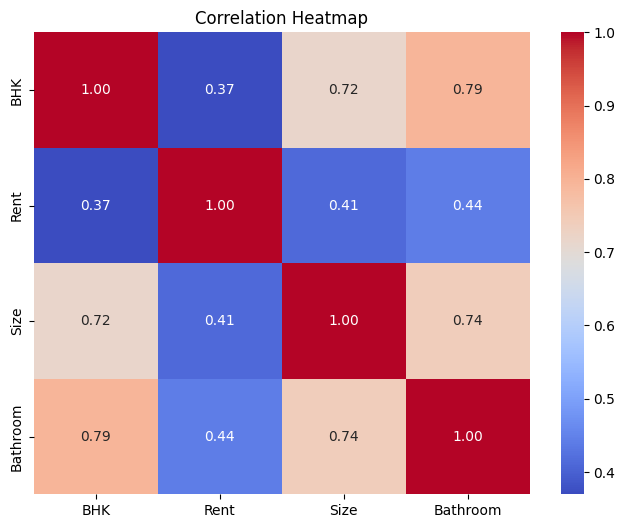

In [ ]:
plt.figure(figsize=(8, 6))

correlation = df[['BHK', 'Rent', 'Size', 'Bathroom']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
correlation['Rent'].sort_values(ascending=False)

,Rent
Rent,1.000000
Bathroom,0.441215
Size,0.413551
BHK,0.369718


### Observation

The correlation analysis shows that Bathroom has the strongest positive correlation with Rent (0.441), followed by Size (0.414) and BHK (0.370). All three numerical features have positive relationships with Rent, indicating that properties with more bathrooms, larger sizes, and more bedrooms generally tend to have higher rental prices. However, the correlations are moderate, suggesting that other factors such as City, Furnishing Status, and Area Type may also contribute to rental prices.

## 15. Final EDA Findings

The exploratory data analysis provided several important insights into the Apartment Rent dataset.

- The dataset contains 4,746 records and 12 columns.
- No missing values were found in the dataset.
- No duplicate records were found.
- The Rent variable is highly spread and contains potential high-value outliers.
- 2 BHK properties are the most common in the dataset.
- Average rent generally increases with the number of bedrooms and bathrooms.
- Property Size has a moderate positive relationship with Rent.
- Bathroom has the strongest numerical correlation with Rent (0.441), followed by Size (0.414) and BHK (0.370).
- Rental prices vary considerably between cities, with Mumbai having the highest average rent among the cities in the dataset.
- Furnished properties have a higher average rent than semi-furnished and unfurnished properties.
- Rent also varies across Area Type and Tenant Preferred categories.

Overall, the EDA suggests that both numerical and categorical features can be useful for predicting apartment rental prices. These findings will be considered during the data preprocessing and regression modeling stages.